Imports

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load Data

In [97]:
df = pd.read_csv("../data/shots_sample.csv")
df.head()

,club_name,ball_speed_mph,launch_angle_deg,azimuth_deg,spin_rpm,spin_axis_deg
0,Driver,155,13,0,2500,0
1,Driver,152,12,2,2700,4
2,Driver,149,11,-3,2900,-6
3,7 Iron,120,18,0,6200,0
4,7 Iron,118,17,1,6400,3


Unit Conversion

In [98]:
MPH_TO_MPS = 0.44704
METERS_TO_YARDS = 1.09361
METERS_TO_FEET = 3.28084

df["ball_speed_mps"] = df["ball_speed_mph"] * MPH_TO_MPS
df["launch_angle_rad"] = np.radians(df["launch_angle_deg"])
df["azimuth_rad"] = np.radians(df["azimuth_deg"])

Simulating Flight

In [99]:
def simulate_flight(vx, vy, vz, spin_axis=0.0, dt=0.01):
    g = 9.81
    drag_coeff = 0.0015
    lift_coeff = 0.0008
    side_coeff = 0.0005

    x, y, z = 0.0, 0.0, 0.0
    positions = []

    while z >= 0:
        v = np.sqrt(vx**2 + vy**2 + vz**2)

        if v == 0:
            break

        drag = drag_coeff * v**2
        lift = lift_coeff * v**2
        side_force = side_coeff * v**2 * spin_axis

        ax = -drag * vx / v
        ay = -drag * vy / v + side_force
        az = -g - (drag * vz / v) + lift
        
        vx += ax * dt
        vy += ay * dt
        vz += az * dt

        x += vx * dt
        y += vy * dt
        z += vz * dt

        positions.append((x, y, z))

    return np.array(positions)

Simple Physics Formulas

In [100]:
g = 9.81

df["vx"] = df["ball_speed_mps"] * np.cos(df["launch_angle_rad"]) * np.cos(df["azimuth_rad"])
df["vy"] = df["ball_speed_mps"] * np.cos(df["launch_angle_rad"]) * np.sin(df["azimuth_rad"])
df["vz"] = df["ball_speed_mps"] * np.sin(df["launch_angle_rad"])

Compute Outcomes

In [101]:
df["flight_time"] = (2 * df["vz"]) / g
df["carry_x_m"] = (df["vx"] * df["flight_time"])
df["carry_y_m"] = (df["vy"] * df["flight_time"])
df["apex_m"] = (df["vz"] ** 2) / (2 * g) 

df[["club_name", "carry_x_m", "carry_y_m", "apex_m"]]

,club_name,carry_x_m,carry_y_m,apex_m
0,Driver,214.550297,0.000000,12.383210
1,Driver,191.319658,6.681030,10.172759
2,Driver,169.190558,-8.866901,8.233111
3,7 Iron,172.426868,0.000000,14.006221
4,7 Iron,158.592731,2.768246,12.123512
5,7 Iron,186.560957,-6.514852,16.069311
6,PW,152.421133,0.000000,20.260939
7,PW,142.521752,2.487726,18.157380
8,PW,162.525520,-2.836893,22.525772


Unit Conversions

In [102]:
df["carry_x_yds"] = df["carry_x_m"] * METERS_TO_YARDS
df["carry_y_yds"] = df["carry_y_m"] * METERS_TO_YARDS

Plot of Dispersion

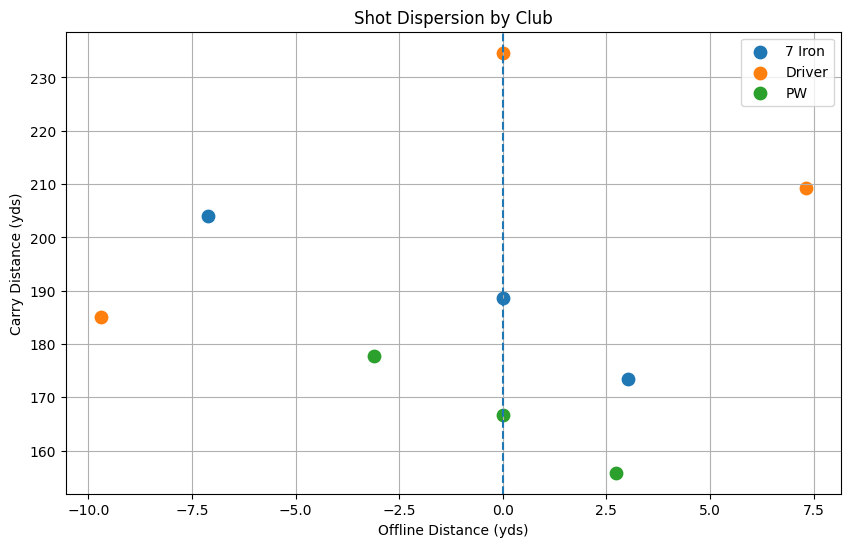

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for club, group in df.groupby("club_name"):
    plt.scatter(group["carry_y_yds"], group["carry_x_yds"], label=club, s=80)

plt.axvline(0, linestyle="--")
plt.xlabel("Offline Distance (yds)")
plt.ylabel("Carry Distance (yds)")
plt.title("Shot Dispersion by Club")
plt.legend()
plt.grid(True)
plt.show()

Monte Carlo Sim

In [104]:
def simulate_shots(row, n=100):
    shots = []

    for _ in range(n):
        speed = np.random.normal(row["ball_speed_mps"], 1.5)
        launch = np.random.normal(row["launch_angle_rad"], 0.02)
        azimuth = np.random.normal(row["azimuth_rad"], 0.02)

        vx = speed * np.cos(launch) * np.cos(azimuth)
        vy = speed * np.cos(launch) * np.sin(azimuth)
        vz = speed * np.sin(launch)

        spin_axis = np.radians(row["spin_axis_deg"])

        traj = simulate_flight(vx, vy, vz, spin_axis=spin_axis)

        if len(traj) == 0:
            continue

        final_x, final_y, _ = traj[-1]
        
        shots.append((final_x, final_y))
        
    return np.array(shots)

In [105]:
sim_data = []

for _, row in df.iterrows():
    sims = simulate_shots(row, n=100)
    
    for x, y in sims:
        sim_data.append({
            "club": row["club_name"],
            "carry_x_m": x,
            "carry_y_m": y
        })

sim_df = pd.DataFrame(sim_data)
sim_df.head()

,club,carry_x_m,carry_y_m
0,Driver,234.555611,-1.149912
1,Driver,256.274043,-1.992261
2,Driver,231.971824,8.085604
3,Driver,261.140892,-3.360972
4,Driver,230.503083,1.272071


Distance Conversions

In [106]:
sim_df["carry_x_yds"] = sim_df["carry_x_m"] * METERS_TO_YARDS
sim_df["carry_y_yds"] = sim_df["carry_y_m"] * METERS_TO_YARDS

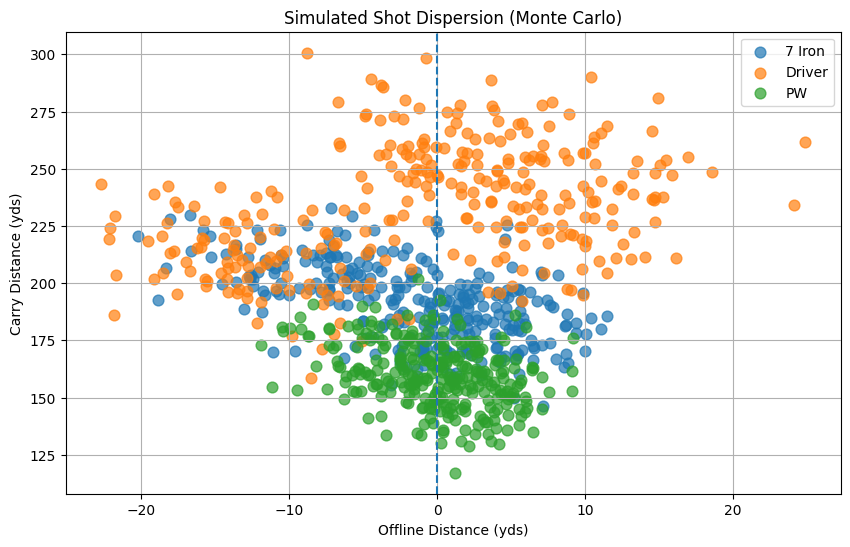

In [107]:
plt.figure(figsize=(10, 6))

for club, group in sim_df.groupby("club"):
    plt.scatter(group["carry_y_yds"], group["carry_x_yds"], label=club, alpha=0.7, s=60)

plt.axvline(0, linestyle="--")
plt.xlabel("Offline Distance (yds)")
plt.ylabel("Carry Distance (yds)")
plt.title("Simulated Shot Dispersion (Monte Carlo)")
plt.legend()
plt.grid(True)
plt.show()